# Tutorial: Fluorescence Signal Quantification in InSituPy

This tutorial demonstrates how to quantify fluorescence signals from microscopy images using the `quantify_signal` function of an `InSituData` object.

## Overview

The `quantify_signal` function allows you to:
- Measure fluorescence intensity in cells from IF images
- Choose between different quantification methods (mean, median, etc.)
- Specify which cellular compartment to analyze (cells or nuclei)
- Automatically add results to your AnnData object

In [1]:
## Ensure all functions are reloaded before execution
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

from insitupy import CACHE, InSituData

## Step 1: Load Your Data

First, we load the InSituPy project and the necessary modalities.

In [3]:
# Read the InSituPy project
insitupy_project = Path(CACHE / "out/demo_insitupy_project")
xd = InSituData.read(insitupy_project)

# Load required modalities
xd.load_images()
xd.load_cells()
xd.load_annotations()

C:\Users\ge37voy\Github\insitupy\insitupy\containers\io.py:328: UserWarning: Saved nucleus_to_cell_map uses the legacy position-based format and is inconsistent with the cell table (likely filtered by an older InSituPy that did not maintain it). Dropping it; nuclei will be treated as 1:1 with cells. Re-read from raw data to restore multinucleated-cell mapping.
  boundaries = _read_boundaries_from_celldata_zarr(bound_path)
C:\Users\ge37voy\Github\insitupy\insitupy\containers\io.py:328: UserWarning: Saved nucleus_to_cell_map uses the legacy position-based format and is inconsistent with the cell table (likely filtered by an older InSituPy that did not maintain it). Dropping it; nuclei will be treated as 1:1 with cells. Re-read from raw data to restore multinucleated-cell mapping.
  boundaries = _read_boundaries_from_celldata_zarr(bound_path)


## Step 2: Inspect Available Data

Let's check what cells and images are available.

In [4]:
# View cell data structure
xd.cells

MultiCellData with main layer 'main'
    table
        AnnData object with n_obs × n_vars = 157600 × 297
        obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden'
        var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
        uns: 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
        obsm: 'X_pca', 'X_umap', 'spatial'
        varm: 'PCs'
        layers: 'counts', 'norm_counts'
        obsp: 'connectivities', 'distances'
    boundaries
        BoundariesData object with 2 entries:
            cells
            nuclei

In [5]:
# Check available images
print("Available images:", list(xd.images.keys()))

Available images: ['CD20', 'HE', 'HER2', 'nuclei']


## Step 3: Quantify Fluorescence Signal

Now we'll quantify the CD20 signal in cells using the median intensity method.

### Parameters:
- `image_name`: Name of the fluorescence image to quantify
- `cells_layer`: Which cell layer to use (None = main layer)
- `cells_compartment`: Which compartment to measure ("cells" or "nuclei")
- `method`: Quantification method ("median" is recommended)
- `add_to_obs`: Whether to add results to the AnnData .obs table

In [6]:
# Quantify CD20 signal with median intensity
xd.quantify_signal(
    image_name="CD20",
    cells_layer=None,
    cells_compartment="cells",
    method="median",
    add_to_obs=True
)

c:\Users\ge37voy\AppData\Local\miniconda3\envs\isp012\Lib\site-packages\skimage\measure\_regionprops.py:379: UserWarning: Extra property 'intensity_median' is shadowed by existing property and will be inaccessible. Consider renaming it.
  warn(msg)


2026-09-10 18:11:22 | [INFO] Added quantification results to `.cells['None'].table.obs['CD20_signal_cells_median']`.


In [7]:
# Quantify CD20 signal with median intensity
xd.quantify_signal(
    image_name="HER2",
    cells_layer=None,
    cells_compartment="cells",
    method="median",
    add_to_obs=True
)

c:\Users\ge37voy\AppData\Local\miniconda3\envs\isp012\Lib\site-packages\skimage\measure\_regionprops.py:379: UserWarning: Extra property 'intensity_median' is shadowed by existing property and will be inaccessible. Consider renaming it.
  warn(msg)


2026-09-10 18:12:19 | [INFO] Added quantification results to `.cells['None'].table.obs['HER2_signal_cells_median']`.


In [8]:
xd.cells

MultiCellData with main layer 'main'
    table
        AnnData object with n_obs × n_vars = 157600 × 297
        obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'CD20_signal_cells_median', 'HER2_signal_cells_median'
        var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
        uns: 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
        obsm: 'X_pca', 'X_umap', 'spatial'
        varm: 'PCs'
        layers: 'counts', 'norm_counts'
        obsp: 'connectivities', 'distances'
    boundaries
        BoundariesData object with 2 entries:
            cells
            nuclei

## Step 4: Inspect the Results

The quantification results are stored in the `.obs` table of your AnnData object.

In [9]:
# View the first few rows of the results
xd.cells.table.obs[['CD20_signal_cells_median']].head()

,CD20_signal_cells_median
2,2.0
5,2.0
8,2.0
10,1.0
13,2.0


In [17]:
# Summary statistics

print("CD20 Signal Statistics:")
print(xd.cells.table.obs['CD20_signal_cells_median'].describe())

CD20 Signal Statistics:
count    157600.000000
mean          2.807697
std           5.253496
min           0.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          85.000000
Name: CD20_signal_cells_median, dtype: float64


## Step 5: Visualize the Results

Let's create some visualizations to explore the quantified signal.

### Interactive visualization

In [ ]:
xd.show()

INFO: Saved color legend to 'C:\Users\ge37voy\Downloads\colorlegend-main-HER2_signal_cells_median.pdf'


### Static plotting

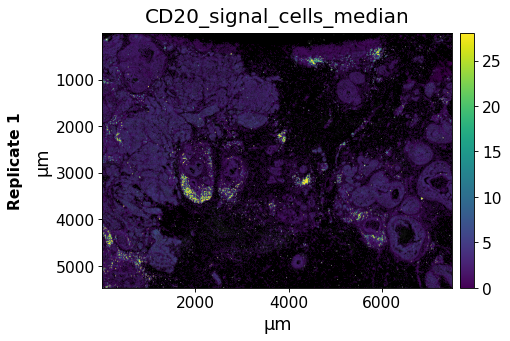

In [11]:
from insitupy.plotting import spatial

spatial(
    data=xd,
    keys='CD20_signal_cells_median',
    image_key='CD20',
)

Plotting of the CD20 image shows that the signals are overlapping very well. To show only the image data we set the spots transparent with `alpha=0`.

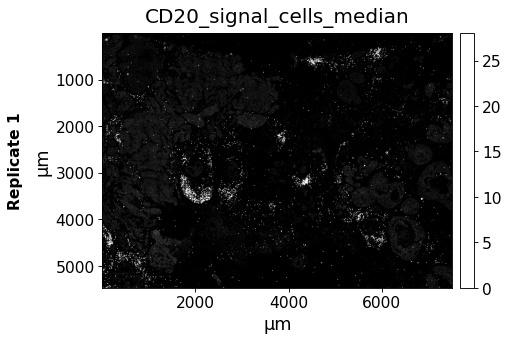

In [12]:
spatial(
    data=xd,
    keys='CD20_signal_cells_median',
    image_key='CD20',
    alpha=0
)

### Quantifying Nuclear Signals

You can also quantify signals in nuclei specifically:

In [13]:
# Quantify signal in nuclei
xd.quantify_signal(
    image_name="CD20",
    cells_layer=None,
    cells_compartment="nuclei",
    method="median",
    add_to_obs=True
)

c:\Users\ge37voy\AppData\Local\miniconda3\envs\isp012\Lib\site-packages\skimage\measure\_regionprops.py:379: UserWarning: Extra property 'intensity_median' is shadowed by existing property and will be inaccessible. Consider renaming it.
  warn(msg)


2026-09-10 22:36:30 | [INFO] Added quantification results to `.cells['None'].table.obs['CD20_signal_nuclei_median']`.


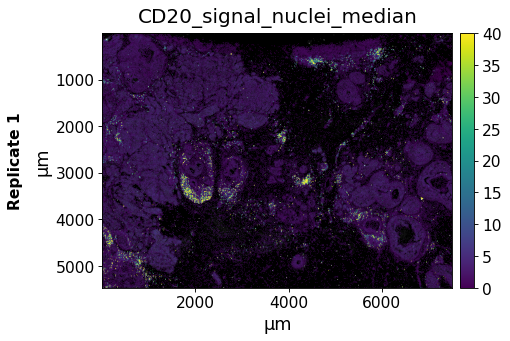

In [14]:
from insitupy.plotting import spatial

spatial(
    data=xd,
    keys='CD20_signal_nuclei_median',
    image_key='CD20',
)

### Processing very large images in memory-efficient manner

In case of very large images, loading the full image into memory can cause problems. For such cases, a memory-efficient tile-based approach is implemented and can be invoked by specifying a `tile_size`. This approach takes longer but requires significantly less memory.

In [15]:
# Quantify signal in nuclei
xd.quantify_signal(
    image_name="CD20",
    cells_layer=None,
    cells_compartment="cells",
    method="median",
    tile_size=4000,
    add_to_obs=True
)

2026-09-10 22:36:40 | [INFO] Quantification using tiled approach with overlap 470...


Processing tiles:   0%|          | 0/88 [00:00<?, ?it/s]c:\Users\ge37voy\AppData\Local\miniconda3\envs\isp012\Lib\site-packages\skimage\measure\_regionprops.py:379: UserWarning: Extra property 'intensity_median' is shadowed by existing property and will be inaccessible. Consider renaming it.
  warn(msg)
Processing tiles: 100%|██████████| 88/88 [01:45<00:00,  1.19s/it]


2026-09-10 22:38:25 | [INFO] Collecting results...
2026-09-10 22:38:47 | [INFO] Added quantification results to `.cells['None'].table.obs['CD20_signal_cells_median']`.


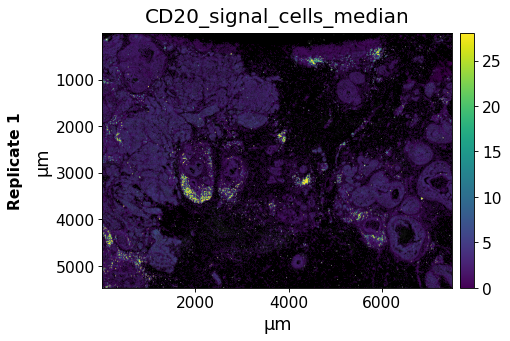

In [16]:
from insitupy.plotting import spatial

spatial(
    data=xd,
    keys='CD20_signal_cells_median',
    image_key='CD20',
)

##